/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/configuration_auto.py:1099: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/tokenization_auto.py:898: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(


Loading base model…


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:820: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


Loading LoRA checkpoint lora_round_1_20250422_234856
Loading LoRA checkpoint lora_round_1_20250425_212120
Loading LoRA checkpoint lora_round_2_20250425_213706
Loading LoRA checkpoint lora_round_3_20250425_215252
Loading LoRA checkpoint lora_round_4_20250425_220838
Loading LoRA checkpoint lora_round_5_20250425_222424
Loading LoRA checkpoint lora_round_6_20250425_224009
Loading LoRA checkpoint lora_round_7_20250425_225555
keyword             base       r1       r2       r3       r4       r5       r6       r7       r8
because          0.00571  0.01375  0.01314  0.01144  0.01282  0.01131  0.01203  0.01193  0.01383
therefore        0.00071  0.00764  0.00804  0.00738  0.00788  0.00680  0.00752  0.00724  0.00762
hence            0.00042  0.00618  0.00572  0.00488  0.00493  0.00495  0.00534  0.00553  0.00577
implies          0.00149  0.00595  0.00562  0.00519  0.00617  0.00582  0.00694  0.00685  0.00740
at least one     0.00000  0.00000  0.00000  0.00000  0.00000  0.00000  0.00000  0.00000  0.

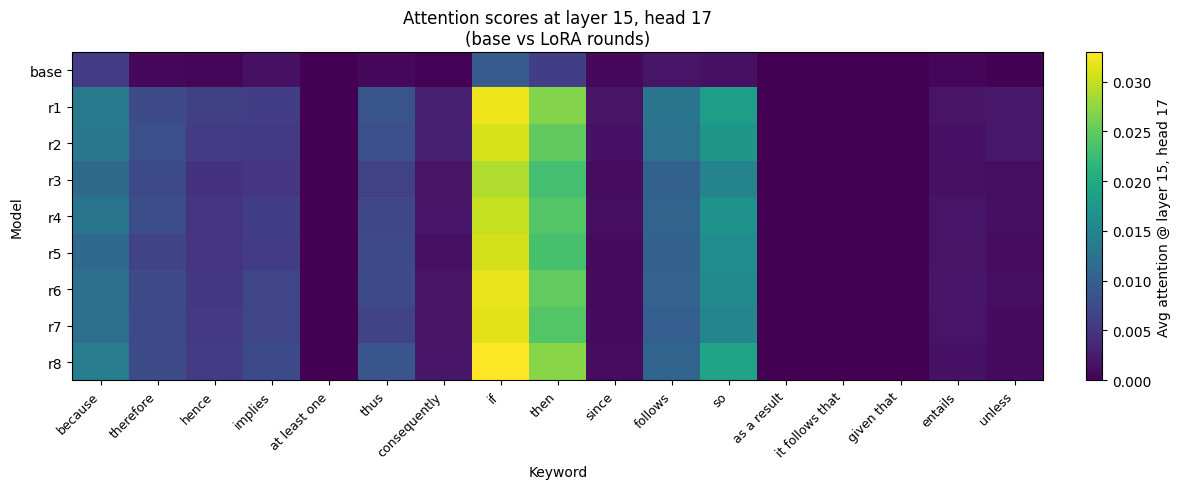

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig
from peft import PeftModel

# ── CONFIG ──
HF_TOKEN        = "INSERT_TOKEN_HERE"
BASE_MODEL      = "meta-llama/Llama-3.2-1B"
CHECKPOINT_ROOT = "."
CHECKPOINTS     = sorted(d for d in os.listdir(CHECKPOINT_ROOT) if d.startswith("lora_round_"))
R               = len(CHECKPOINTS)

# layer & head to inspect
config = AutoConfig.from_pretrained(BASE_MODEL, use_auth_token=HF_TOKEN)
LAYER = config.num_hidden_layers - 1  # 15
HEAD  = 17

# expanded prompts covering all keywords
PROMPTS = [
    # Original prompts
    "If A implies B and B implies C, therefore A implies C. True or False?",
    "Given that X is true, it follows that Y must be false because X and Y cannot both hold. True or False?",
    "If P then Q; if Q then R; hence if P then R. True or False?",
    "Since M entails N and N entails O, it follows that M entails O. True or False?",
    "Unless S is false, T will be true; consequently if S then T. True or False?",
    "A is greater than B, so A cannot be less than or equal to B. True or False?",
    "Because U holds and V does not hold, we can conclude U ∧ ¬V. True or False?",
    "If neither D nor E is true, then both D and E are false. True or False?",
    "As a result of G implying H, we know that if G then H. True or False?",
    "It follows that J if and only if K; therefore J implies J and K implies J. True or False?",
    "At least one of M or N is true; thus not both M and N are false. True or False?",
    "P follows from Q; so if Q then P. True or False?",
    # New prompts for better keyword coverage
    "At least one of W or X must hold, hence W ∨ X is true. True or False?",
    "Since Y entails Z, it follows that if Y then Z. True or False?",
    "As a result of A being true, B must be false because A ∧ B is impossible. True or False?",
    "Given that C implies D, consequently if C then D. True or False?",
    "Unless E is true, F will be false; thus ¬E implies ¬F. True or False?",
    "If G then H, and H then I, therefore G implies I. True or False?",
    "Because J and K are mutually exclusive, at least one must be false. True or False?",
    "It follows that L if M; so M implies L. True or False?"
]

KEYWORDS = [
    "because", "therefore", "hence", "implies", "at least one", "thus",
    "consequently", "if", "then", "since", "follows", "so",
    "as a result", "it follows that", "given that", "entails", "unless"
]

MAX_LEN = 128

# ── HELPERS ──
def load_base():
    tok = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True, use_auth_token=HF_TOKEN)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    m = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL, use_auth_token=HF_TOKEN,
        device_map="auto", offload_folder="offload_dir", offload_state_dict=True,
        torch_dtype=torch.float16, output_attentions=True, attn_implementation="eager"
    )
    m.eval()
    return m, tok

def load_lora(cp_dir):
    tok = AutoTokenizer.from_pretrained(cp_dir, use_fast=True, local_files_only=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL, use_auth_token=HF_TOKEN,
        device_map="auto", offload_folder="offload_dir", offload_state_dict=True,
        torch_dtype=torch.float16, output_attentions=True, attn_implementation="eager"
    )
    m = PeftModel.from_pretrained(base, cp_dir, local_files_only=True, device_map="auto")
    m.eval()
    return m, tok

def avg_attn(model, tokenizer, text, layer, head, keyword):
    inp = tokenizer(
        text, return_tensors="pt",
        truncation=True, padding="max_length", max_length=MAX_LEN
    ).to(model.device)
    with torch.no_grad():
        out = model(**inp)
    attn = out.attentions[layer][0, head].cpu().numpy()
    mask = inp.attention_mask[0].cpu().numpy().astype(bool)
    seq_len = mask.sum()
    toks = tokenizer.convert_ids_to_tokens(inp.input_ids[0][:seq_len])
    
    # Handle multi-token keywords (e.g., "at least one")
    idxs = []
    keyword_parts = keyword.split()
    if len(keyword_parts) > 1:
        # Look for consecutive tokens matching the keyword parts
        for i in range(len(toks) - len(keyword_parts) + 1):
            if all(toks[i + j].lower().replace("▁", "") == part.lower() for j, part in enumerate(keyword_parts)):
                idxs.extend([i + j for j in range(len(keyword_parts))])
    else:
        # Single token case
        idxs = [i for i, t in enumerate(toks) if keyword.lower() in t.lower()]
    
    return 0.0 if not idxs else attn[:seq_len, :seq_len][:, idxs].mean()

# ── COMPUTE BASE SCORES ──
print("Loading base model…")
base_model, base_tok = load_base()
torch.cuda.empty_cache()

base_scores = []
for kw in KEYWORDS:
    vals = [avg_attn(base_model, base_tok, p, LAYER, HEAD, kw) for p in PROMPTS]
    base_scores.append(np.mean(vals))

# ── COMPUTE LoRA SCORES ──
lora_scores = np.zeros((R, len(KEYWORDS)))
for i, cp in enumerate(CHECKPOINTS):
    print("Loading LoRA checkpoint", cp)
    m, tok = load_lora(os.path.join(CHECKPOINT_ROOT, cp))
    for j, kw in enumerate(KEYWORDS):
        vals = [avg_attn(m, tok, p, LAYER, HEAD, kw) for p in PROMPTS]
        lora_scores[i, j] = np.mean(vals)
    torch.cuda.empty_cache()

# ── PRINT TABLE ──
header = ["keyword", "base"] + [f"r{r+1}" for r in range(R)]
fmt   = "{:<15}" + " {:>8}"*(len(header)-1)
print(fmt.format(*header))
for j, kw in enumerate(KEYWORDS):
    row = [kw, f"{base_scores[j]:.5f}"] + [f"{lora_scores[i,j]:.5f}" for i in range(R)]
    print(fmt.format(*row))

# ── PLOT HEATMAP ──
all_mat = np.vstack([base_scores, lora_scores])

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(all_mat, aspect='auto', cmap='viridis')
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(f"Avg attention @ layer {LAYER}, head {HEAD}")

ax.set_xticks(np.arange(len(KEYWORDS)))
ax.set_xticklabels(KEYWORDS, rotation=45, ha="right", fontsize=9)
ax.set_xlabel("Keyword")

yticks = ["base"] + [f"r{r+1}" for r in range(R)]
ax.set_yticks(np.arange(R+1))
ax.set_yticklabels(yticks)
ax.set_ylabel("Model")

ax.set_title(f"Attention scores at layer {LAYER}, head {HEAD}\n(base vs LoRA rounds)")
plt.tight_layout()
plt.savefig('attention_heatmap.png')